In [3]:
!pip install tf-levenberg-marquardt 

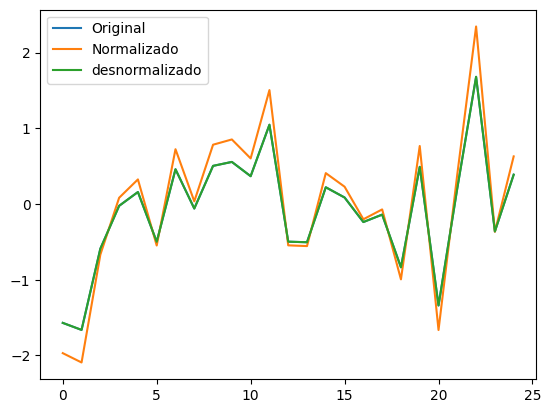

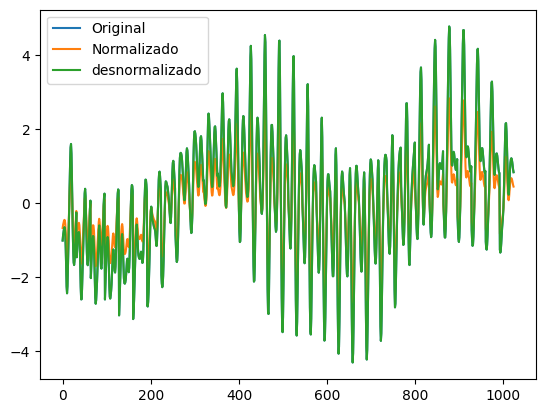

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def peaks(grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    return x, y, z

def create_dataframe_(filepaths, grid):
    x, y, z = peaks(grid)
    z_pred_total = np.zeros_like(z).ravel()
    for filepath in filepaths:
        z_pred = pd.read_excel(filepath, usecols=['Z_pred']).squeeze('columns').to_numpy()
        z_pred_total += z_pred
    z_residuo= z.flatten() - (z_pred_total)
    data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z_residuo}
    df = pd.DataFrame(data)
    return df
 
def create_dataframe(grid):
   x, y, z = peaks(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()

arquivos_25 = [
    "25_model_13_2_14.xlsx",
    "25_model_12_6_0.xlsx",
    "25_model_33_7_2.xlsx",
    "25_model_29_7_11.xlsx"
]
arquivos_1000 = [
    "1000_model_13_2_14.xlsx",
    "1000_model_12_6_0.xlsx",
    "1000_model_33_7_2.xlsx",
    "1000_model_29_7_11.xlsx"
]
df_25 = create_dataframe_(arquivos_25, grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe_(arquivos_1000,grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [5]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [6]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-11-05 22:09:58.077896: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-05 22:09:58.111814: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-05 22:09:58.111862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-05 22:09:58.113175: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-05 22:09:58.119632: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-05 22:09:58.120417: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [7]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [8]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] >= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)
 
  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [9]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='r2',
            boundarie = 0.7,
            hidden_sizes = [[3], [4], [5], [6], [7], [8], [9], [11]],
            regularizers=[0.2, 0.05],
            learning_rate=[0.01, 0.1]) 

Testando combinacao1: Hidden Size=[3], regularizer=0.2, learning_rate=0.01
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++


Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  19
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 9 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 10 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_5_4_23,0.857487,-0.724617,0.862921,-1.398045,0.224095,0.388488,4.701295,0.168809,1.198616,0.683713,0.978304,0.623288,0.511385,0.649823,35.890985,56.611874
model_5_4_22,0.851362,-1.133357,0.804352,-1.383805,0.187208,0.405186,5.815516,0.240936,1.191498,0.716217,1.034489,0.636543,0.490384,0.663642,35.806816,56.527705
model_5_4_21,0.847247,-1.472511,0.800779,-1.391537,0.182518,0.416404,6.740049,0.245336,1.195363,0.720350,1.085919,0.645294,0.476274,0.672766,35.752196,56.473085
model_5_4_20,0.845953,-1.743062,0.784337,-1.387371,0.172211,0.419932,7.477567,0.265584,1.193281,0.729432,1.094904,0.648022,0.471838,0.675609,35.735325,56.456214
model_5_4_0,0.703289,-2.078205,0.579524,-1.923316,-0.122906,0.808832,8.391164,0.517805,1.461162,0.989484,2.480627,0.899351,-0.017295,0.937638,34.424328,55.145217
model_5_4_19,0.841066,-3.210577,0.755110,-1.388023,0.151604,0.433253,11.478003,0.301575,1.193606,0.747591,1.148097,0.658219,0.455084,0.686241,35.672868,56.393757
model_5_4_8,0.823786,-3.761671,0.873327,-1.493686,0.204242,0.480359,12.980281,0.155994,1.246420,0.701207,1.410031,0.693079,0.395837,0.722585,35.466444,56.187333
model_5_4_9,0.824738,-4.170390,0.871160,-1.487856,0.204381,0.477764,14.094446,0.158663,1.243506,0.701085,1.400591,0.691205,0.399100,0.720631,35.477276,56.198165
model_5_4_7,0.822265,-4.303333,0.872584,-1.501654,0.201462,0.484503,14.456850,0.156910,1.250403,0.703656,1.429022,0.696063,0.390624,0.725695,35.449263,56.170152
model_5_4_11,0.826614,-4.500081,0.866199,-1.478289,0.203628,0.472649,14.993181,0.164772,1.238724,0.701748,1.381290,0.687495,0.405534,0.716763,35.498805,56.219694


DataFrame salvo em content/results/metrics_5_4
+++++++++++ [5_5] | 1 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 2ms/step
+++++++++++ [5_5] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [5_5] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [5_5] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [5_5] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [5_5] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [5_5] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [5_5] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [5_5] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_5_5_24,0.774704,-0.125564,-0.318910,0.578808,0.361736,0.614155,3.068279,2.348257,1.378165,1.863211,1.025312,0.783681,0.227557,0.817044,34.975015,55.695904
model_5_5_23,0.779258,-0.165760,-0.301941,0.595149,0.376069,0.601742,3.177854,2.318043,1.324696,1.821369,1.027726,0.775720,0.243169,0.808744,35.015852,55.736741
model_5_5_22,0.788178,-0.175790,-0.265168,0.627256,0.405277,0.577426,3.205194,2.252571,1.219639,1.736105,1.047431,0.759885,0.273753,0.792235,35.098351,55.819240
model_5_5_21,0.796308,-0.222348,-0.229022,0.656121,0.432477,0.555264,3.332112,2.188214,1.125194,1.656704,1.063378,0.745160,0.301627,0.776883,35.176625,55.897514
model_5_5_20,0.797098,-0.258902,-0.226183,0.658977,0.434944,0.553109,3.431757,2.183160,1.115849,1.649505,1.062297,0.743713,0.304337,0.775374,35.184402,55.905291
model_5_5_19,0.805092,-0.457319,-0.222058,0.702207,0.460430,0.531317,3.972641,2.175816,0.974397,1.575106,1.070524,0.728915,0.331745,0.759946,35.264793,55.985682
model_5_5_4,0.850020,-0.472087,0.063716,0.988081,0.707794,0.408845,4.012899,1.667008,0.039001,0.853004,1.124468,0.639410,0.485782,0.666631,35.788839,56.509728
model_5_5_5,0.848635,-0.479581,0.012950,0.986464,0.691406,0.412620,4.033327,1.757396,0.044290,0.900843,1.174456,0.642355,0.481034,0.669702,35.770456,56.491345
model_5_5_3,0.853372,-0.494285,0.136965,0.992313,0.732503,0.399706,4.073409,1.536592,0.025154,0.780873,1.060156,0.632223,0.497277,0.659138,35.834052,56.554941
model_5_5_6,0.849095,-0.495430,-0.026323,0.985746,0.679027,0.411365,4.076532,1.827319,0.046639,0.936979,1.173464,0.641377,0.482613,0.668682,35.776548,56.497438


...

DataFrame salvo em content/results/metrics_32_7
+++++++++++ [32_8] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_32_8_0,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_8_22,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_8_21,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_8_20,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_8_19,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_8_18,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_8_17,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_8_16,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_8_15,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_8_14,0.857346,0.246396,1.0,0.481887,0.828669,0.388875,2.05432,1.350723e-12,1.627962,0.813981,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409


DataFrame salvo em content/results/metrics_32_8
+++++++++++ [32_9] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [32_9] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_32_9_0,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_9_22,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_9_21,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_9_20,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_9_19,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_9_18,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_9_17,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_9_16,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_9_15,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409
model_32_9_14,0.857346,0.246396,0.934365,1.0,0.979628,0.388875,2.05432,0.141278,4.811029e-13,0.070639,0.792306,0.623598,1.163033,0.650146,91.888997,146.738409


DataFrame salvo em content/results/metrics_32_9
